In [4]:
import scanpy as sc
import os
import pandas as pd
import matplotlib as mpl
import sys
import numpy as np
import matplotlib.pyplot as plt
sys.path.append('/Users/amossi/Documents/code/')
import FISHspace as sp
%reload_ext autoreload
%autoreload 2

mpl.rcParams['pdf.fonttype'] = 42

# save figure with no pad
mpl.rcParams['savefig.pad_inches'] = 0
mpl.rcParams['savefig.bbox'] = 'tight'

# set axes width
mpl.rcParams['axes.linewidth'] = 2
mpl.rcParams['xtick.minor.pad'] = 2
mpl.rcParams['xtick.major.pad'] = 2
mpl.rcParams['ytick.minor.pad'] = 2
mpl.rcParams['ytick.major.pad'] = 2
mpl.rcParams['xtick.minor.width'] = 2
mpl.rcParams['xtick.major.width'] = 2
mpl.rcParams['ytick.minor.width'] = 2
mpl.rcParams['ytick.major.width'] = 2


In [ ]:
eel_path = '../../data_for_visualization/GBM_Linnarsson_EEL_revision.h5ad'
adata = sc.read_h5ad(eel_path)

In [ ]:
#adata.write_h5ad('../../data_for_visualization/GBM_Linnarsson_EEL_revision.h5ad')

In [39]:
adata.obs['m-states'].cat.categories

Index(['AC-like 1', 'AC-like 2', 'AC-like 3', 'AC-like 4', 'AC-like 5',
       'AC-like 6', 'AC-like 7', 'Astrocyte', 'DC', 'Endothelial',
       'Erythrocyte', 'FB-like 1', 'FB-like 2', 'FB-like 3', 'GBL-like 1',
       'GBL-like 2', 'Mono 1', 'Mono 2', 'Mural cell 1', 'Mural cell 2',
       'OPC-like 1', 'OPC-like 2', 'Oligodendrocyte', 'RG-like', 'TAM-BDM 1',
       'TAM-BDM 2', 'TAM-BDM 3', 'TAM-BDM 4', 'TAM-MG', 'WR 1', 'WR 2', 'WR 3',
       'WR 4', 'WR 5', 'WR 6', 'WR 7', 'WR 8', 'nIPC-RG-like', 'nIPC-like 1',
       'nIPC-like 2', 'nIPC-like 3', 'preOPC-like', 'unknown'],
      dtype='object')

In [40]:
palette = {
    'AC-like 1':'#2ecc71',#inchworm B4FF9F
    'AC-like 2':'#2ecc71',#inchworm B4FF9F
    'AC-like 3':'#2ecc71',#inchworm B4FF9F
    'AC-like 4':'#2ecc71',#inchworm B4FF9F
    'AC-like 5':'#2ecc71',#inchworm B4FF9F
    'AC-like 6':'#2ecc71',#inchworm B4FF9F
    'AC-like 7':'#2ecc71',#inchworm B4FF9F

    'preOPC-like':'#7befb2',#'#c2f970'

    'WR 2': '#EDE8F3',
    'WR 3': '#E2D8EA',
    'WR': '#D6BEDD',
    'WR 5': '#CFA8D1',
    'WR 4': '#CA90C5',
    'WR 7': '#D873B6',
    'WR 8': '#e76d89',#'#C50F53',
    'WR 6': '#e76d89',#'#840034',
        
    'nIPC-like 1':'#FFF192',
    'nIPC-like 2':'#FFF192',
    'nIPC-like 2':'#FFF192',
    
        
    'nIPC-RG-like 1':'#ff9470',
    'RG-like':'#ff9470',
    
    'OPC-like 1':'#89c4f4', #bright turquoise
    'OPC-like 2':'#89c4f4', #bright turquoise

    'Endothelial':'#8c14fc',#'#d5b8ff', #mauve
    'Mural cell 1': '#8c14fc',  #electric indigo
    'Mural cell 2': '#8c14fc',  #electric indigo
    
    'FB-like 1': '#FF6EC7', #fff9de
    'FB-like 2': '#FF6EC7', #fff9de
    'FB-like 3': '#FF6EC7', #fff9de

    'Mono 1': '#c8f7c5',#'#e6d9cb',#'#cdd1e4',#'#f4ede4',
    'Mono 2': '#FBFCFA', 
    
    'TAM-BDM 1':'#e88474',#'#F5C9B0',
    'TAM-BDM 2':'#A94A54',
    
    'TAM-BDM 3':'#89c4f4',#'#95a5a6',#'#ecd9dd',
    'TAM-BDM 4':'#DC9D57',#'#A5765C',
    
    'TAM-MG':'#825e5c', #'#00b5cc' (blue),
    
    'DC': '#a6915c',
}

In [41]:
SL040 = adata[np.array([True if s.count('SL040') else False for s in adata.obs.Sample ])]

In [43]:

# Noted below the updated gene naWR (Neftel had some old gene symbols)
WR1 = np.array(["CHI3L1","ANXA2","ANXA1","CD44","VIM","MT2A","C1S","NAMPT","EFEMP1","C1R","SOD2","IFITM3","TIMP1","SPP1","A2M","S100A11","MT1X","S100A10","FN1","LGALS1","S100A16","CLIC1","MGST1","RCAN1","TAGLN2","NPC2","SERPING1","TCIM","EMP1","APOE","CTSB","C3","LGALS3","MT1E","EMP3","SERPINA3","ACTN1","PRDX6","IGFBP7","SERPINE1","PLP2","MGP","CLIC4","GFPT2","GSN","NNMT","TUBA1C","GJA1","TNFRSF1A","WWTR1"])
WR2 = np.array(["HILPDA","ADM","DDIT3","NDRG1","HERPUD1","DNAJB9","TRIB3","ENO2","AKAP12","SQSTM1","MT1X","ATF3","NAMPT","NRN1","SLC2A1","BNIP3","LGALS3","INSIG2","IGFBP3","PPP1R15A","VIM","PLOD2","GBE1","SLC2A3","FTL","WARS1","ERO1A","XPOT","HSPA5","GDF15","ANXA2","EPAS1","LDHA","P4HA1","SERTAD1","PFKP","PGK1","EGLN3","SLC6A6","CA9","BNIP3L","RPL21","TRAM1","UFM1","ASNS","GOLT1B","ANGPTL4","SLC39A14","CDKN1A","HSPA9"])
WR = np.concatenate((WR1, WR2))

WR =WR[np.isin(WR, adata.var_names.values)]

def compute_WR_score(adata):

    genes =adata.var_names
    n_genes = len(genes)
    expression = adata.X
    total_umi = adata.X.sum(axis=1)
    expression = (expression.T / total_umi).T * np.median(total_umi)
    expression = expression - np.mean(expression, axis=0)
    
    expression_order = np.argsort(adata.X.sum(axis=0))
    genes = genes[expression_order]
    expression = expression[:, expression_order]

    bin_size = n_genes // 10

    def gene_signature_score(signature_genes):
        score = np.mean(expression[:, np.isin(genes, signature_genes)], axis=1)
        control_genes = np.zeros(n_genes, dtype=bool)
        for g in signature_genes:
            ix = np.where(genes == g)[0][0]
            ix = min(ix, n_genes - bin_size)  # Make sure the last bin is complete
            random50 = np.random.choice(bin_size, size=50, replace=False)
            control_genes[random50 + ix // bin_size * bin_size] = True
        control_score = np.mean(expression[:, control_genes], axis=1)
        return score - control_score

    WR_score = gene_signature_score(WR)

    return WR_score

In [44]:
SL040.obsm['WRscore'] = compute_WR_score(SL040)


/var/folders/wt/ft7rv1yx7152d1skc4w_cvbh0000gp/T/ipykernel_29239/1467824494.py:1: ImplicitModificationWarning: Setting element `.obsm['WRscore']` of view, initializing view as actual.
  SL040.obsm['WRscore'] = compute_WR_score(SL040)


In [45]:
vmin = SL040.obsm['WRscore'].min()
vmax = SL040.obsm['WRscore'].max()

In [46]:
dic_zones = {
    'SL040B': 'Ant high fluo',
    'SL040J': 'Sup no fluo',
    'SL040K': 'Inf no fluo',
    'SL040C': 'Ant low fluo',
    'SL040D': 'Ant no fluo',
    'SL040I': 'Sup low fluo',
    'SL040E': 'Pos high fluo',
    'SL040A': 'Cortex',
    'SL040F': 'Pos no fluo',
    'SL040G': 'Necrotic core',
    'SL040H': 'Sup high fluo',
    'SL040L': 'Inf high fluo'
}

In [47]:
SL040.obs['m-states'].cat.categories

Index(['AC-like 1', 'AC-like 2', 'AC-like 3', 'AC-like 4', 'AC-like 5',
       'AC-like 6', 'AC-like 7', 'Astrocyte', 'Endothelial', 'Erythrocyte',
       'FB-like 1', 'FB-like 2', 'GBL-like 1', 'GBL-like 2', 'Mono 1',
       'Mono 2', 'Mural cell 1', 'Mural cell 2', 'OPC-like 1', 'OPC-like 2',
       'Oligodendrocyte', 'RG-like', 'TAM-BDM 1', 'TAM-BDM 2', 'TAM-BDM 3',
       'TAM-BDM 4', 'TAM-MG', 'WR 1', 'WR 3', 'WR 4', 'WR 5', 'WR 6', 'WR 7',
       'WR 8', 'nIPC-RG-like', 'nIPC-like 1', 'nIPC-like 2', 'nIPC-like 3',
       'preOPC-like', 'unknown'],
      dtype='object')

INFO:root:First filter, 1525 cells left
INFO:root:Zoom filter, 1525 cells left


WRscore (1525, 878) KeysView(AxisArraysView with keys: spatial, WRscore)
0.3780557 -0.16082914


/Users/amossi/Documents/code/FISHspace/plotting/polygons.py:565: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  gdf_gray.plot(color=gray_color,edgecolor='black',linewidth=0.05,ax=ax1,rasterized=True,facecolor=facecolor, alpha=alpha_gray)


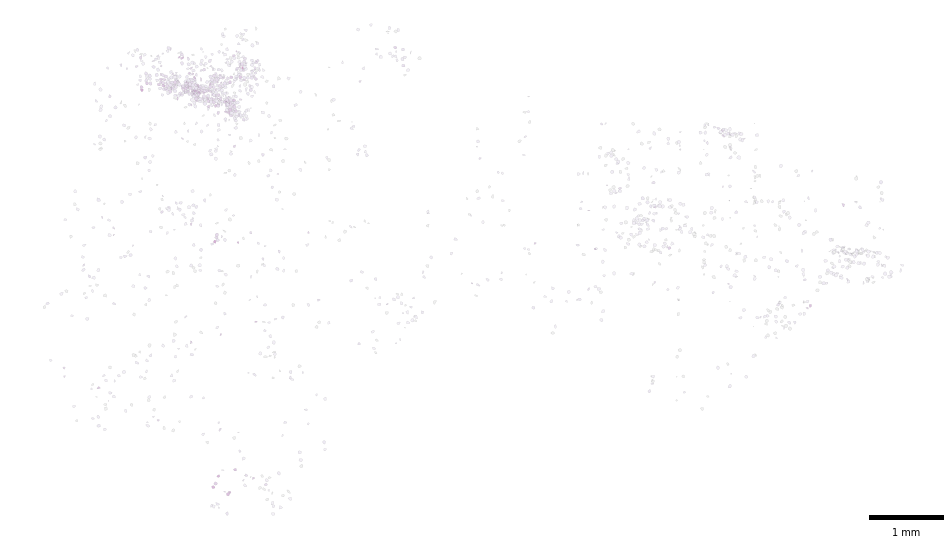

In [48]:
# Core
sp.pl.plot_polygons_obsm(
    SL040,
    sample = 'SL040G',
    key= 'WRscore',
    cluster_key='m-states',
    clusters = SL040.obs['m-states'].cat.categories.tolist(),
    cmap='PuRd',
    vmin=vmin,
    vmax=vmax,
)

In [49]:
glia_color = '#93faa5'

palette_wound = {
    
    'TAM-MG':'#00b5cc',
    'TAM-BDM 3':'#d5b8ff',
    'TAM-BDM 4':'#d5b8ff',
     
    'AC-like 4':glia_color,
    'AC-like 5':glia_color,
    'AC-like 2':glia_color,
    'AC-like 1':glia_color,
    'AC-like 3':glia_color,
    'AC-like 6':glia_color,
    'AC-like 7':glia_color,

    'GBL-like 1':glia_color,
    'GBL-like 2':glia_color,

    'preOPC-like 1':glia_color,

    'nIPC-like 1':glia_color,
    'nIPC-like 2':glia_color,
    'nIPC-like 3':glia_color, 

    'RG-like':glia_color,
    'nIPC-RG-like':glia_color,

    'OPC-like 1':glia_color,
    'OPC-like 2':glia_color, 
    
    'FB-like 1':glia_color,#'#ff9470',
    'FB-like 2':glia_color,#'#ff9470',
    'FB-like 3':glia_color,#'#ff9470',
    
    'Astrocyte': '#16a085',
    'Oligodendrocyte 1':'#392e4a',
    'Oigodendrocyte 2':'#392e4a',
    
    'Mono 1':'#5a228b',
    'Mono 2':'#5a228b',
    'WR 8': '#c44d56',
    'WR 6': '#c44d56',

}

In [52]:
glia_color = '#93faa5'

palette_wound = {
    #'TAM-MG':'#00b5cc',
    #'TAM-BDM 3':'#d5b8ff',
    #'TAM-BDM 4':'#d5b8ff',
    
    'AC-like 4':glia_color,
    'AC-like 5':glia_color,
    'AC-like 2':glia_color,
    'AC-like 1':glia_color,
    'AC-like 3':glia_color,
    'AC-like 6':glia_color,
    'AC-like 7':glia_color,
    'AC-like 8':glia_color,
    
    'Oligodendrocyte 1':'#392e4a',
    'Oigodendrocyte 2':'#392e4a',
    
    'Mono 1':'#d5b8ff',
    'Mono 2':'#d5b8ff',
    
    'Astrocyte': '#038aff',
    
    'WR 8': '#c44d56',
    'WR 6': '#c44d56',

}

INFO:root:First filter, 123 cells left
INFO:root:Zoom filter, 123 cells left
/Users/amossi/Documents/code/FISHspace/plotting/polygons.py:138: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  _ = gdf[gdf[cluster_key].isin(grey_clusters)].plot(
/Users/amossi/Documents/code/FISHspace/plotting/polygons.py:163: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  im = gdf_.plot(color= palette[c], edgecolor='black',linewidth=linewidth, ax=ax1,rasterized=True,facecolor=facecolor,alpha=alpha)
/Users/amossi/Documents/code/FISHspace/plotting/polygons.py:163: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  im = gdf_.plot(color= palette[c], edgecolor='black',linewidth=linewidth, ax=ax1,rasterized=True,facecolor=facecolor,alpha=alpha)
/Users/amossi/Documents/code/FISHspace/plotting/polygons.py:163: UserWarning: The GeoDataFrame you are attempting to plot is em

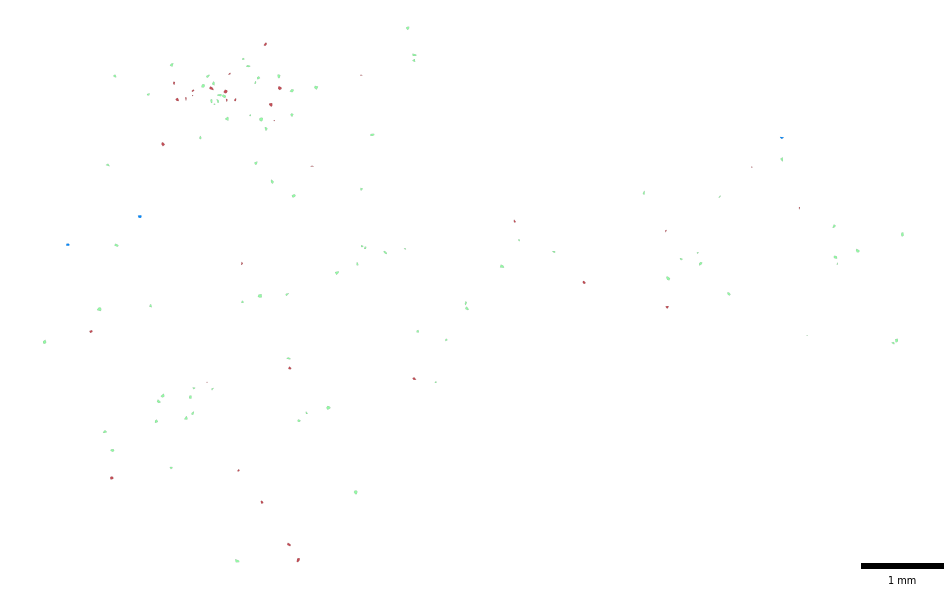

In [54]:
# Core
sp.pl.plot_polygons(
    SL040,
    sample = 'SL040G',
    cluster_key='m-states',
    clusters = list(palette_wound.keys()),
    palette= palette_wound,
    alpha=1,
    save=True,
    savepath='figures/SL040G.png'

)

INFO:root:First filter, 32676 cells left
INFO:root:Zoom filter, 32676 cells left
/Users/amossi/Documents/code/FISHspace/plotting/polygons.py:138: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  _ = gdf[gdf[cluster_key].isin(grey_clusters)].plot(
/Users/amossi/Documents/code/FISHspace/plotting/polygons.py:163: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  im = gdf_.plot(color= palette[c], edgecolor='black',linewidth=linewidth, ax=ax1,rasterized=True,facecolor=facecolor,alpha=alpha)
/Users/amossi/Documents/code/FISHspace/plotting/polygons.py:163: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  im = gdf_.plot(color= palette[c], edgecolor='black',linewidth=linewidth, ax=ax1,rasterized=True,facecolor=facecolor,alpha=alpha)
/Users/amossi/Documents/code/FISHspace/plotting/polygons.py:163: UserWarning: The GeoDataFrame you are attempting to plot i

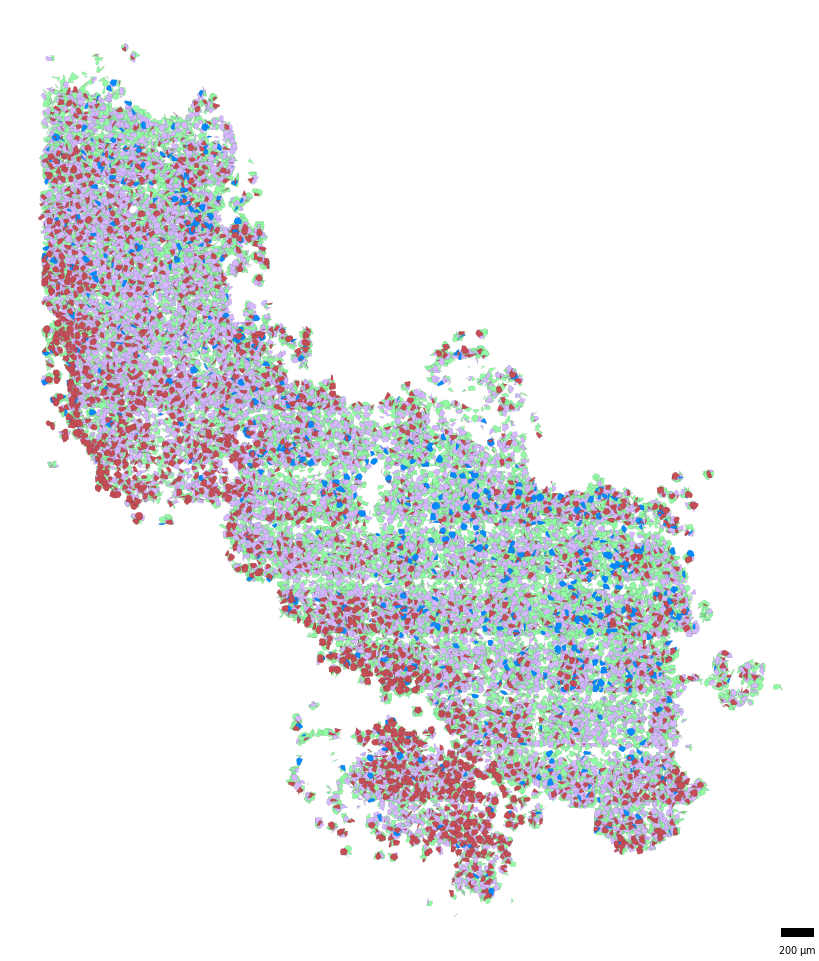

In [55]:
# High
sp.pl.plot_polygons(
    SL040,
    sample = 'SL040B',
    cluster_key='m-states',
    clusters = list(palette_wound.keys()),
    palette= palette_wound,
    alpha=1,
    save=True,
    savepath='figures/SL040B.png'

)

INFO:root:First filter, 41552 cells left
INFO:root:Zoom filter, 41552 cells left
/Users/amossi/Documents/code/FISHspace/plotting/polygons.py:138: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  _ = gdf[gdf[cluster_key].isin(grey_clusters)].plot(
/Users/amossi/Documents/code/FISHspace/plotting/polygons.py:163: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  im = gdf_.plot(color= palette[c], edgecolor='black',linewidth=linewidth, ax=ax1,rasterized=True,facecolor=facecolor,alpha=alpha)
/Users/amossi/Documents/code/FISHspace/plotting/polygons.py:163: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  im = gdf_.plot(color= palette[c], edgecolor='black',linewidth=linewidth, ax=ax1,rasterized=True,facecolor=facecolor,alpha=alpha)
/Users/amossi/Documents/code/FISHspace/plotting/polygons.py:163: UserWarning: The GeoDataFrame you are attempting to plot i

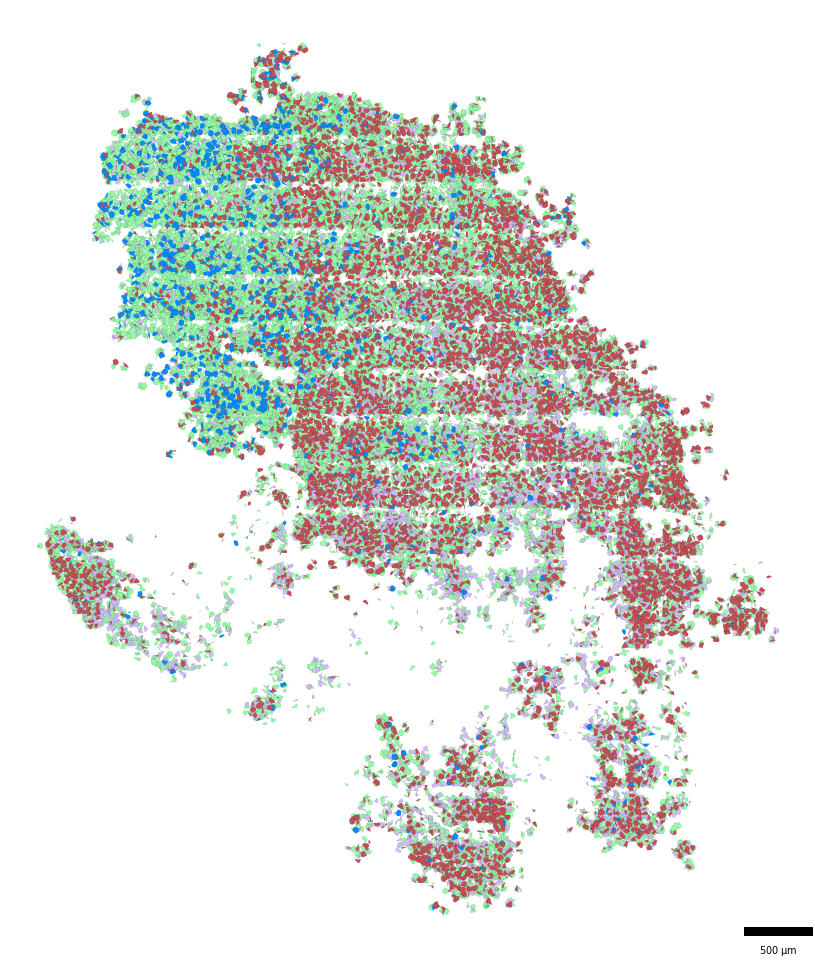

In [56]:
# High
sp.pl.plot_polygons(
    SL040,
    sample = 'SL040E',
    cluster_key='m-states',
    clusters = list(palette_wound.keys()),
    palette= palette_wound,
    alpha=1,
    save=True,
    savepath='figures/SL040E.png'
)

INFO:root:First filter, 6667 cells left
INFO:root:Zoom filter, 6667 cells left
/Users/amossi/Documents/code/FISHspace/plotting/polygons.py:138: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  _ = gdf[gdf[cluster_key].isin(grey_clusters)].plot(
/Users/amossi/Documents/code/FISHspace/plotting/polygons.py:163: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  im = gdf_.plot(color= palette[c], edgecolor='black',linewidth=linewidth, ax=ax1,rasterized=True,facecolor=facecolor,alpha=alpha)
/Users/amossi/Documents/code/FISHspace/plotting/polygons.py:163: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  im = gdf_.plot(color= palette[c], edgecolor='black',linewidth=linewidth, ax=ax1,rasterized=True,facecolor=facecolor,alpha=alpha)
/Users/amossi/Documents/code/FISHspace/plotting/polygons.py:163: UserWarning: The GeoDataFrame you are attempting to plot is 

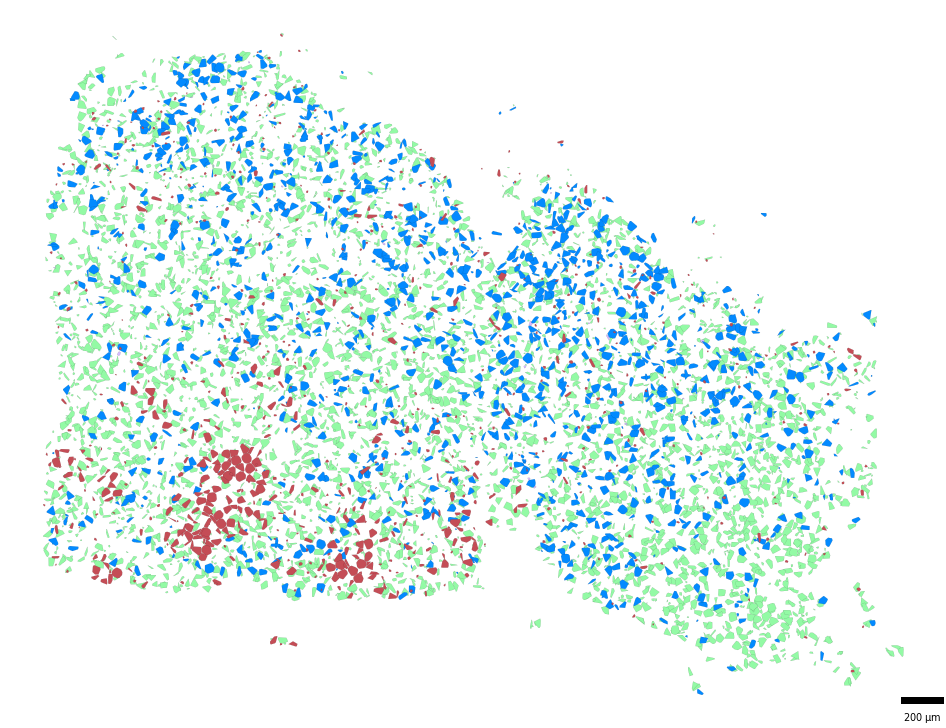

In [57]:
# Low
sp.pl.plot_polygons(
    SL040,
    sample = 'SL040C',
    cluster_key='m-states',
    clusters = list(palette_wound.keys()),
    palette= palette_wound,
    alpha=1,
    save=True,
    savepath='figures/SL040C.png'
)

INFO:root:First filter, 7473 cells left
INFO:root:Zoom filter, 7473 cells left
/Users/amossi/Documents/code/FISHspace/plotting/polygons.py:138: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  _ = gdf[gdf[cluster_key].isin(grey_clusters)].plot(
/Users/amossi/Documents/code/FISHspace/plotting/polygons.py:163: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  im = gdf_.plot(color= palette[c], edgecolor='black',linewidth=linewidth, ax=ax1,rasterized=True,facecolor=facecolor,alpha=alpha)
/Users/amossi/Documents/code/FISHspace/plotting/polygons.py:163: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  im = gdf_.plot(color= palette[c], edgecolor='black',linewidth=linewidth, ax=ax1,rasterized=True,facecolor=facecolor,alpha=alpha)
/Users/amossi/Documents/code/FISHspace/plotting/polygons.py:163: UserWarning: The GeoDataFrame you are attempting to plot is 

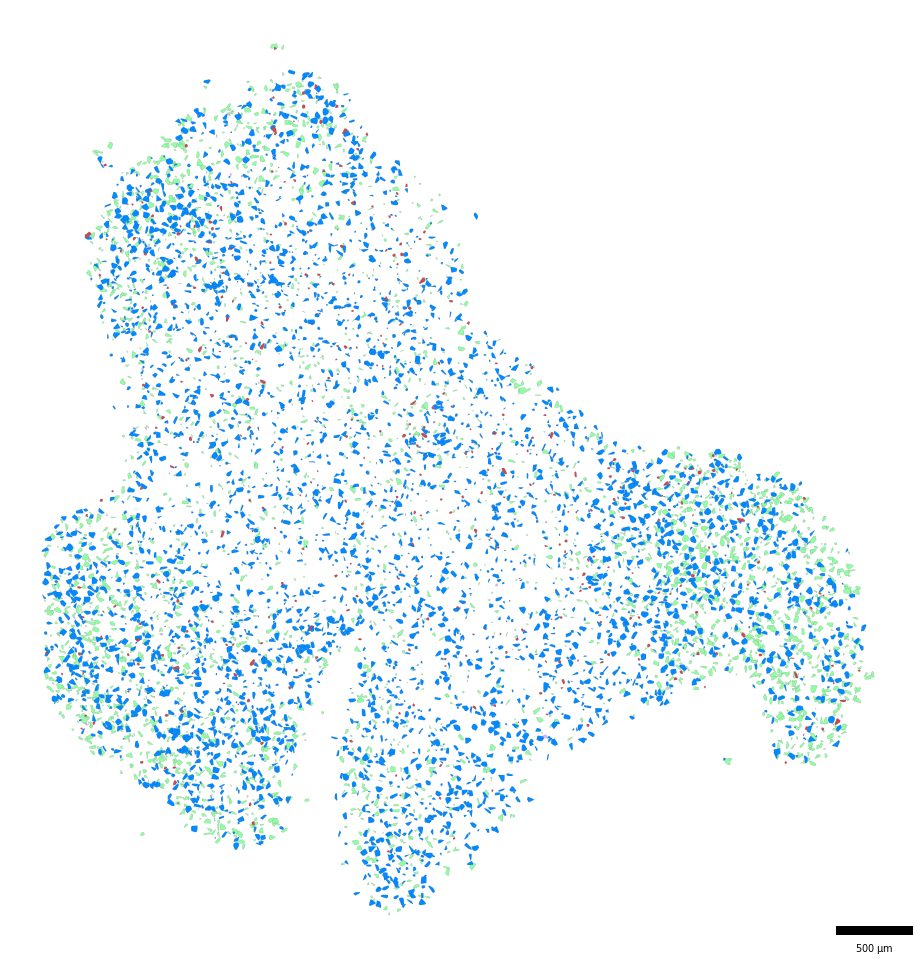

In [58]:
# Low
sp.pl.plot_polygons(
    SL040,
    sample = 'SL040D',
    cluster_key='m-states',
    clusters = list(palette_wound.keys()),
    palette= palette_wound,
    alpha=1,
    save=True,
    savepath='figures/SL040D.png'

)

INFO:root:First filter, 13660 cells left
INFO:root:Zoom filter, 13660 cells left
/Users/amossi/Documents/code/FISHspace/plotting/polygons.py:138: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  _ = gdf[gdf[cluster_key].isin(grey_clusters)].plot(
/Users/amossi/Documents/code/FISHspace/plotting/polygons.py:163: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  im = gdf_.plot(color= palette[c], edgecolor='black',linewidth=linewidth, ax=ax1,rasterized=True,facecolor=facecolor,alpha=alpha)
/Users/amossi/Documents/code/FISHspace/plotting/polygons.py:163: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  im = gdf_.plot(color= palette[c], edgecolor='black',linewidth=linewidth, ax=ax1,rasterized=True,facecolor=facecolor,alpha=alpha)
/Users/amossi/Documents/code/FISHspace/plotting/polygons.py:163: UserWarning: The GeoDataFrame you are attempting to plot i

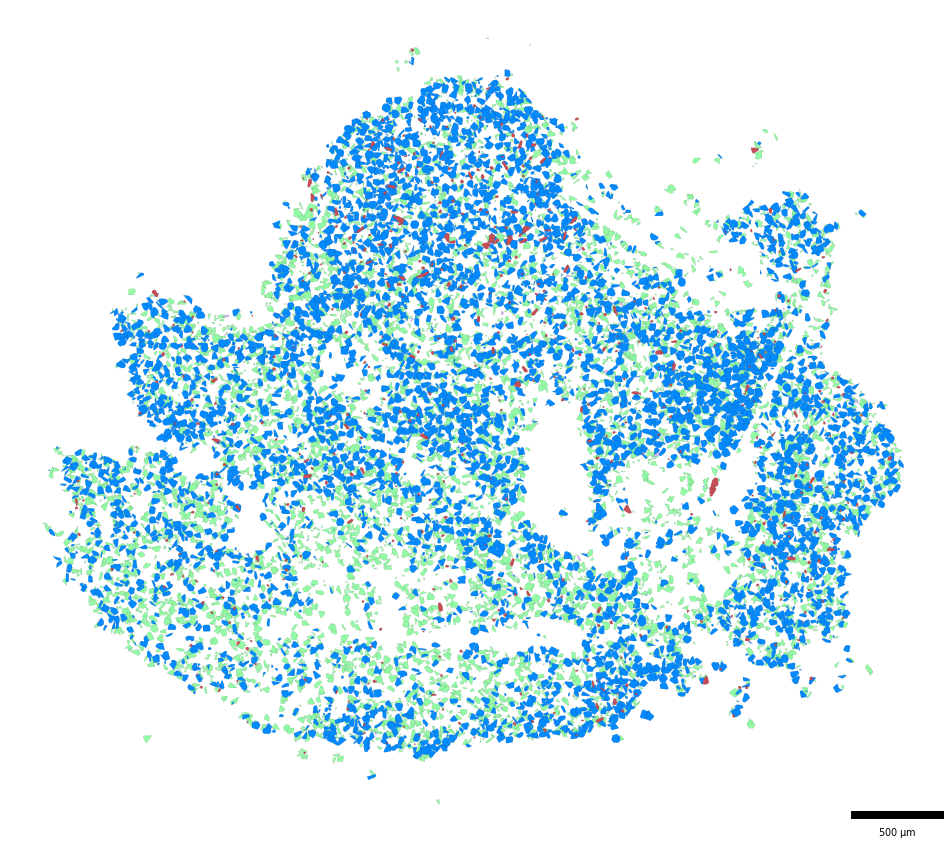

In [59]:
# Periphery
sp.pl.plot_polygons(
    SL040,
    sample = 'SL040F',
    cluster_key='m-states',
    clusters = list(palette_wound.keys()),
    palette= palette_wound,
    alpha=1,
    save=True,
    savepath='figures/SL040F.png'
)

INFO:root:First filter, 83282 cells left
INFO:root:Zoom filter, 83282 cells left


WRscore (83282, 878) KeysView(AxisArraysView with keys: spatial, WRscore)
1.1596233 -0.16947697


/Users/amossi/Documents/code/FISHspace/plotting/polygons.py:565: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  gdf_gray.plot(color=gray_color,edgecolor='black',linewidth=0.05,ax=ax1,rasterized=True,facecolor=facecolor, alpha=alpha_gray)


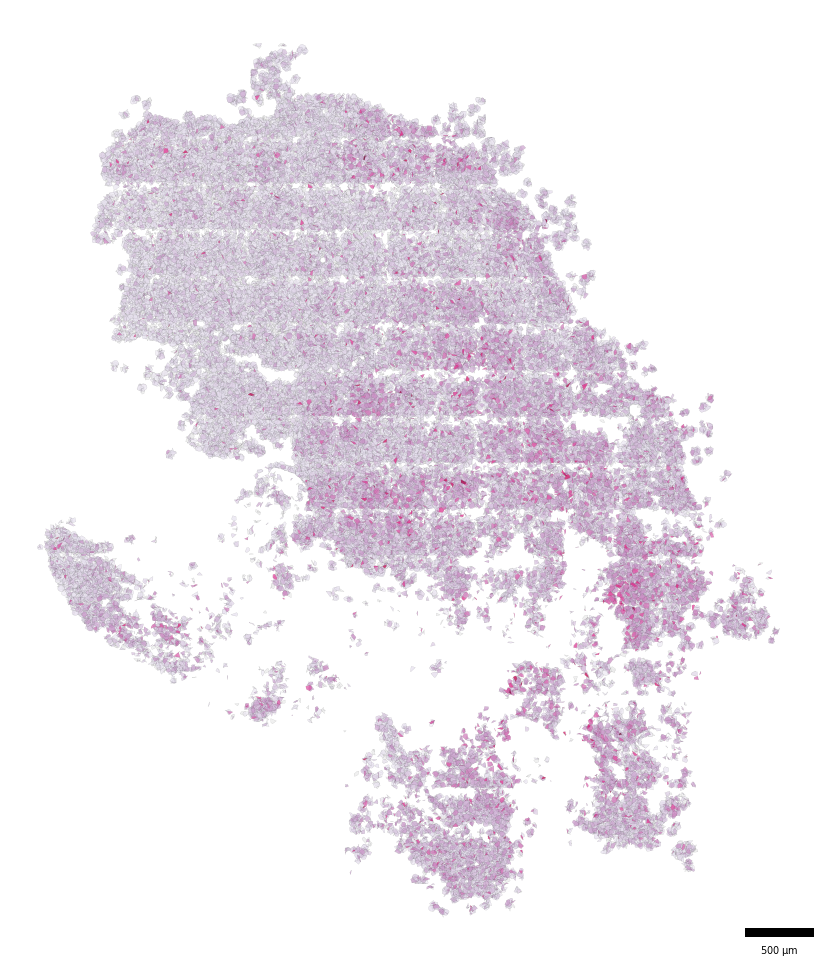

In [60]:
# High
sp.pl.plot_polygons_obsm(
    SL040,
    sample = 'SL040E',
    key= 'WRscore',
    cluster_key='m-states',
    clusters = SL040.obs['m-states'].cat.categories.tolist(),
    cmap='PuRd',
    vmin=vmin,
    vmax=vmax,
    save=True,
    savepath='figures/SL040E_wound.png'
)

INFO:root:First filter, 80554 cells left
INFO:root:Zoom filter, 80554 cells left


WRscore (80554, 878) KeysView(AxisArraysView with keys: spatial, WRscore)
1.177584 -0.16947697


/Users/amossi/Documents/code/FISHspace/plotting/polygons.py:565: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  gdf_gray.plot(color=gray_color,edgecolor='black',linewidth=0.05,ax=ax1,rasterized=True,facecolor=facecolor, alpha=alpha_gray)


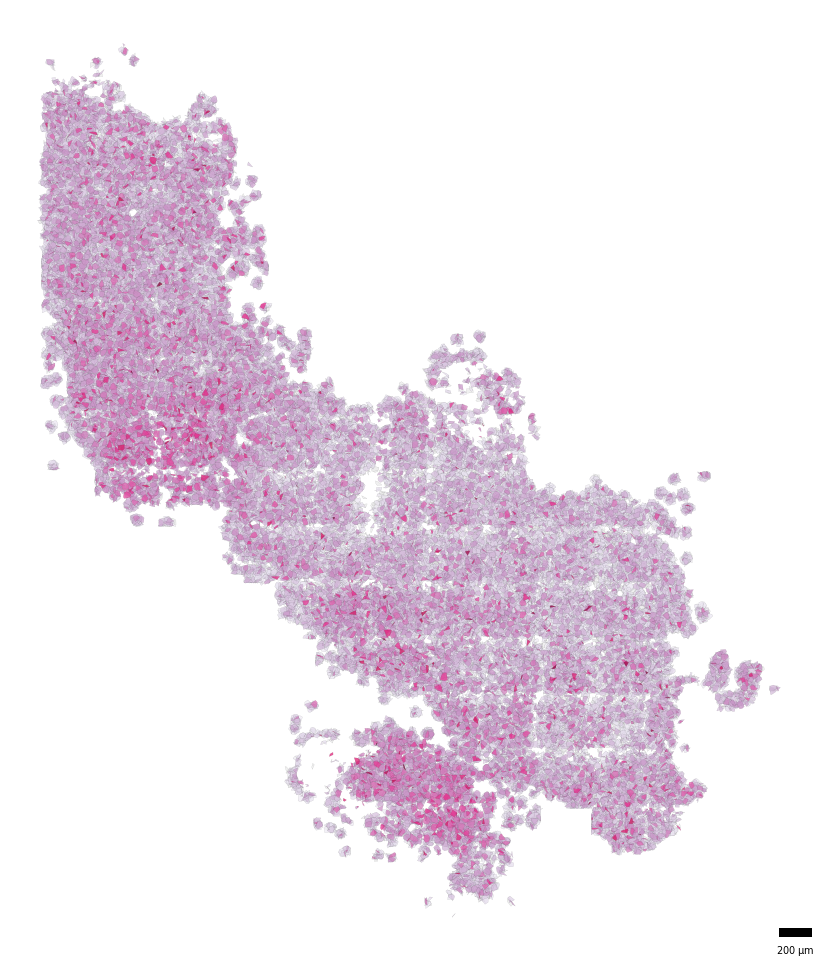

In [61]:
# High
sp.pl.plot_polygons_obsm(
    SL040,
    sample = 'SL040B',
    key= 'WRscore',
    cluster_key='m-states',
    clusters = SL040.obs['m-states'].cat.categories.tolist(),
    cmap='PuRd',
    vmin=vmin,
    vmax=vmax,
    save=True,
    savepath='figures/SL040B_wound.png'
)

INFO:root:First filter, 21190 cells left
INFO:root:Zoom filter, 21190 cells left


WRscore (21190, 878) KeysView(AxisArraysView with keys: spatial, WRscore)
0.5615947 -0.16947694


/Users/amossi/Documents/code/FISHspace/plotting/polygons.py:565: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  gdf_gray.plot(color=gray_color,edgecolor='black',linewidth=0.05,ax=ax1,rasterized=True,facecolor=facecolor, alpha=alpha_gray)


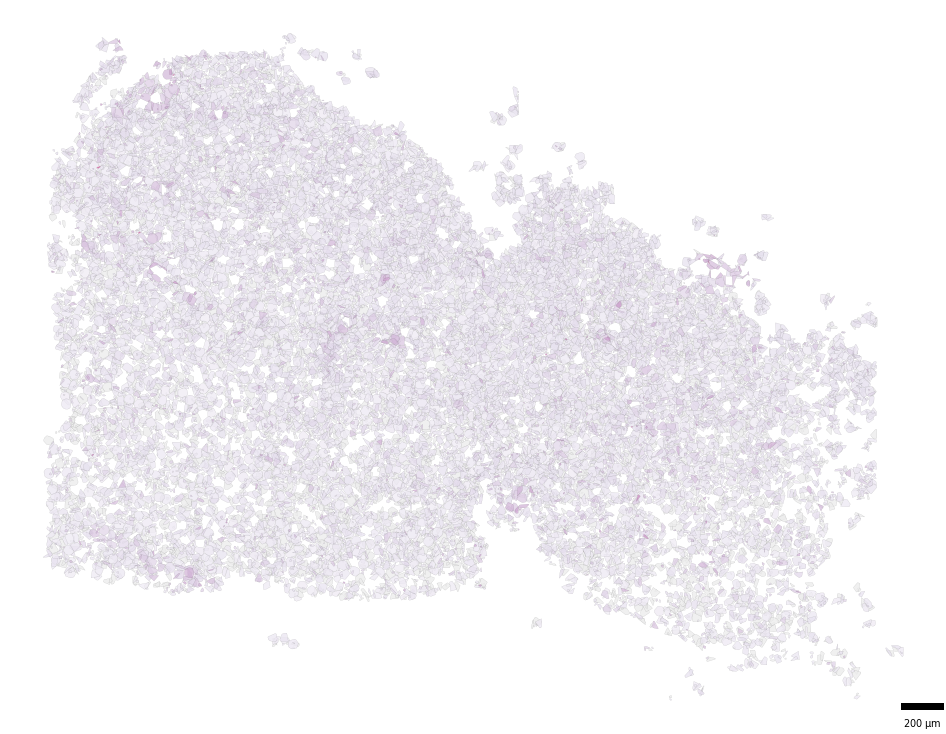

In [62]:
# Low
sp.pl.plot_polygons_obsm(
    SL040,
    sample = 'SL040C',
    key= 'WRscore',
    cluster_key='m-states',
    clusters = SL040.obs['m-states'].cat.categories.tolist(),
    cmap='PuRd',
    vmin=vmin,
    vmax=vmax,
    
    save=True,
    savepath='figures/SL040C_wound.png'
)

INFO:root:First filter, 32160 cells left


WRscore (32160, 878) KeysView(AxisArraysView with keys: spatial, WRscore)
0.42056906 -0.16947694


INFO:root:Zoom filter, 32160 cells left
/Users/amossi/Documents/code/FISHspace/plotting/polygons.py:565: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  gdf_gray.plot(color=gray_color,edgecolor='black',linewidth=0.05,ax=ax1,rasterized=True,facecolor=facecolor, alpha=alpha_gray)


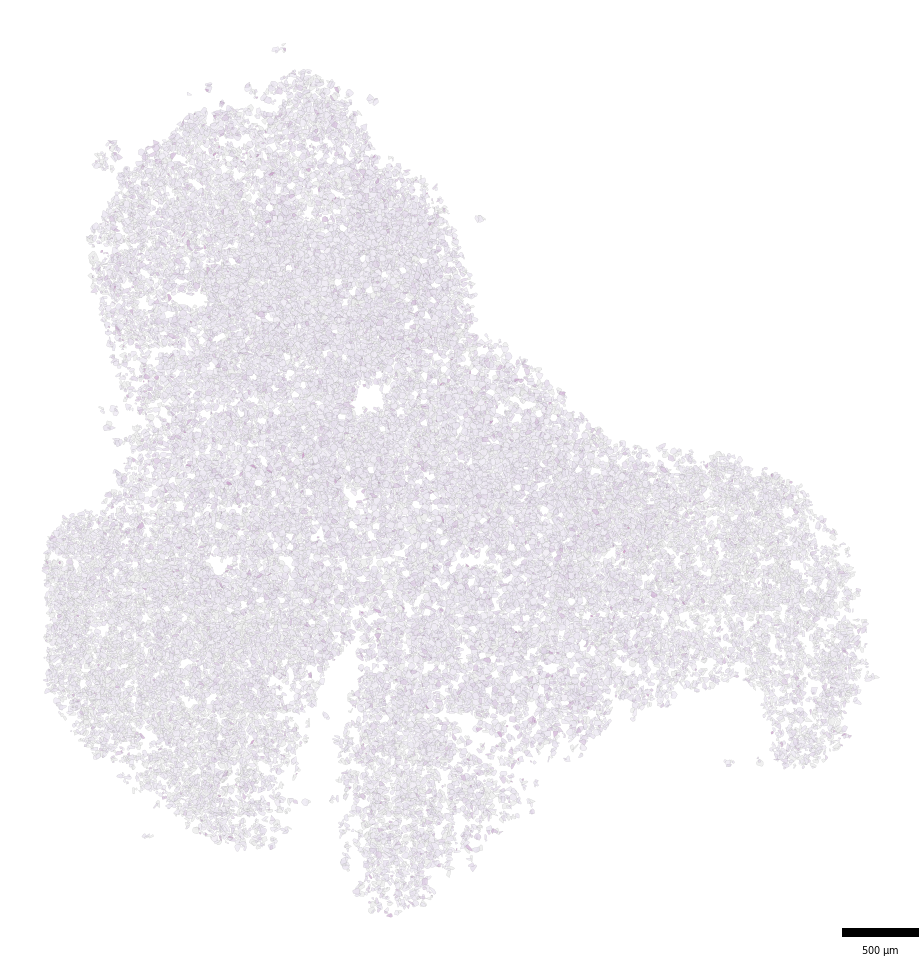

In [63]:
# Periphery
sp.pl.plot_polygons_obsm(
    SL040,
    sample = 'SL040D',
    key= 'WRscore',
    cluster_key='m-states',
    clusters = SL040.obs['m-states'].cat.categories.tolist(),
    cmap='PuRd',
    vmin=vmin,
    vmax=vmax,
    
    save=True,
    savepath='figures/SL040D_wound.png'
)

INFO:root:First filter, 28724 cells left
INFO:root:Zoom filter, 28724 cells left


WRscore (28724, 878) KeysView(AxisArraysView with keys: spatial, WRscore)
0.4975677 -0.16947694


/Users/amossi/Documents/code/FISHspace/plotting/polygons.py:565: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  gdf_gray.plot(color=gray_color,edgecolor='black',linewidth=0.05,ax=ax1,rasterized=True,facecolor=facecolor, alpha=alpha_gray)


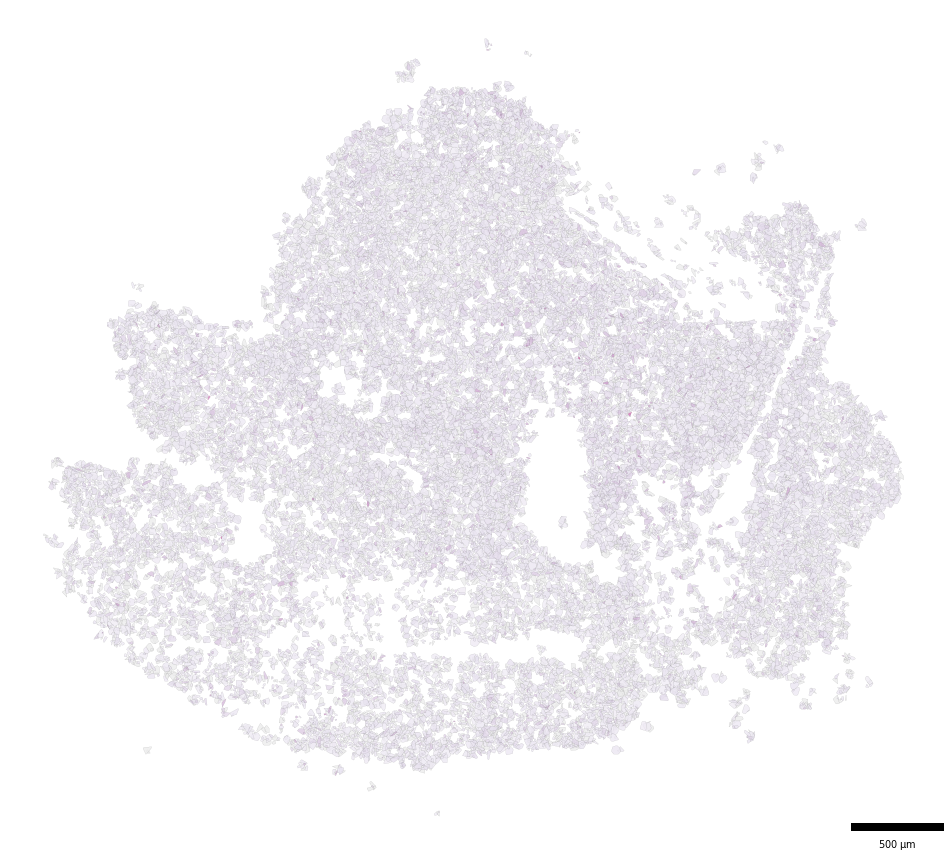

In [64]:
# Periphery
sp.pl.plot_polygons_obsm(
    SL040,
    sample = 'SL040F',
    key= 'WRscore',
    cluster_key='m-states',
    clusters = SL040.obs['m-states'].cat.categories.tolist(),
    cmap='PuRd',
    vmin=vmin,
    vmax=vmax,
    
    save=True,
    savepath='figures/SL040F_wound.png'
)

INFO:root:First filter, 1525 cells left
INFO:root:Zoom filter, 1525 cells left


WRscore (1525, 878) KeysView(AxisArraysView with keys: spatial, WRscore)
0.3780557 -0.16082914


/Users/amossi/Documents/code/FISHspace/plotting/polygons.py:565: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  gdf_gray.plot(color=gray_color,edgecolor='black',linewidth=0.05,ax=ax1,rasterized=True,facecolor=facecolor, alpha=alpha_gray)


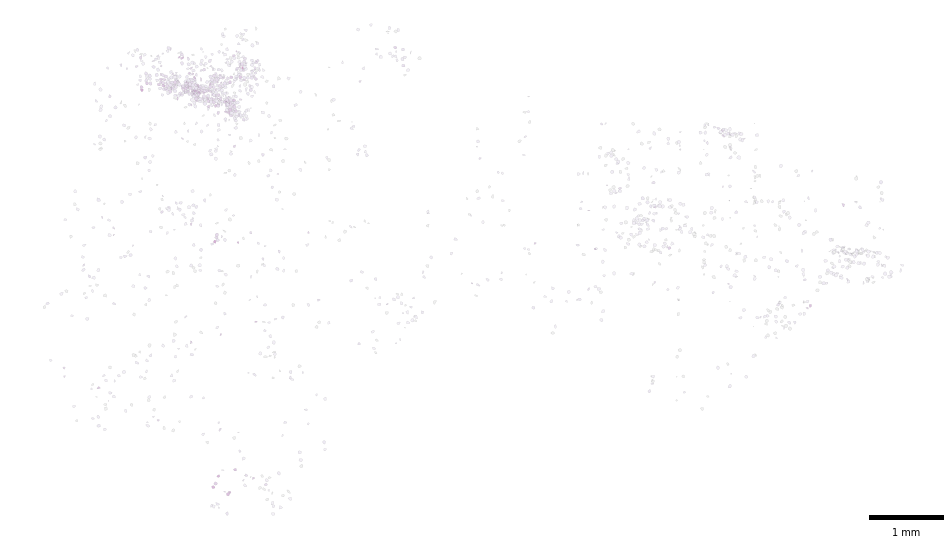

In [65]:
# Periphery
sp.pl.plot_polygons_obsm(
    SL040,
    sample = 'SL040G',
    key= 'WRscore',
    cluster_key='m-states',
    clusters = SL040.obs['m-states'].cat.categories.tolist(),
    cmap='PuRd',
    vmin=vmin,
    vmax=vmax,
    
    save=True,
    savepath='figures/SL040G_wound.png'
)